# **NLP 2026 Group Project**

---

Authors: Hosein Mohebbi & Giovanni Cassani

---

This notebook is part of the Natural Language Processing (Spring 2026) course and is designed to replicate some of the experiments presented in [How Many Data Points is a Prompt Worth?](https://aclanthology.org/2021.naacl-main.208/)
The main goal of this project is to investigate two common approaches (head-based and prompt-based) to fine-tuning large language models for classification tasks.

## Introduction

Before everything, let's quickly go over some key terminology, including the main stages of LLM development: pre-training and fine-tuning, and two fine-tuning approaches: head-based and prompt-based, used throughout this project.

### __Pre-training__
Large language models (LLMs) are pre-trained using self-supervised learning objectives such as masked language modeling or next-token prediction over massive corpora.
Architecturally, a language modeling head (a linear classifier) followed by a softmax operation maps the final hidden representations (outputed from a stack of Transformer layers) to a probability distribution over the whole vocabulary. The training objective is to maximize the likelihood of the correct masked/next token given the context. Through this objective, the base model learns rich internal representations that capture broad, task-agnostic properties of language, including lexical semantics and syntactic structure. These pre-trained representations provide a good initialization that can be effectively adapted for various downstream applications.

### __Fine-tuning__
Fine-tuning means further training the base model for a few steps on supervised, task-specific data to help it adapt to a particular task. This adaptation is achieved by adjusting the model's parameters (all or partial weights) through gradient-based updates. In this project, we compare two commonly-used fine-tuning approaches:

__head-based__ tuning: a conventional approach where the base model is coupled with a newly initialized classification head and is fine-tuned to predict the categorized output class.

__prompt-based__ tuning: where we reformulate the input examples in the dataset as __cloze-style__ prompts, in which one token is intentionally masked and the model is asked to fill in the blank. For instance, consider the task of sentiment analysis, where the goal is to classify a review as either positive or negative. Given the input text:
> _Excellent pizza! Slices are fantastic, prices are reasonable._

Instead of training a classifier on top of the model to map the sentence representation to discrete output classes (e.g., 0 for positive and 1 for negative), prompt-based tuning reformulates the task as a cloze-style prediction problem. Specifically, the input could be rewritten as:
> Excellent pizza! Slices are fantastic, prices are reasonable. The restaurant is ___

The model is then asked to predict a word for the blank position. Ideally, it outputs "good" if the review is positive (class 0) and "bad" if the review is negative (class 1). In general, this approach requires two things. First, a __pattern__, which is a function that reformulates the original input into a cloze-style prompt. Second, a __verbalizer__, which maps each possible output class to a single token in the model's vocabulary.

Interestingly, the input and output format in __prompt-based__ fine-tuning approach aligns very well with the pre-training objective that is used to pre-train the base models (masked language modeling or next-token prediction). This makes this approach especially useful in low-resource settings, where only limited fine-tuning data is available as there is no need to train a new classifier from scratch: the approach leverages the already pre-trained language model head and repurposes it for classification. In this regards, the paper aims to compare the sample efficiency of the two approaches to answer _"how many data points is a prompt worth?"_
The following notebook is provided to help students fine-tune the models to replicate some of the experiments presented in the paper.

In [ ]:
# @title Install Requirements
!pip install transformers datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.7 MB/s eta 0:00:00


In [ ]:
# @title Imports required libraries
import numpy as np
import torch
from torch.utils.data import DataLoader
from transformers import default_data_collator
from torch.optim import AdamW
from datasets import load_dataset
from transformers import RobertaTokenizer, RobertaConfig, RobertaForMaskedLM, RobertaForSequenceClassification
from evaluate import load as load_metric


In [ ]:
# @title Select GPU
if torch.cuda.is_available():
    device = torch.device(f"cuda:0")
    print('We will use the GPU:', torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print('No GPU available, using the CPU instead.')


We will use the GPU: Tesla T4


## Models

Here, we load pre-trained weights of the RoBERTa model (pre-trained by the masked language modeling objective) using the HuggingFace's Transformers library.

__RobertaForSequenceClassification__ loads the pre-trained RoBERTa model and attaches a newly initialized classification head. This head applies a linear projection to the hidden state of the special \<s\> (beginning-of-sequence) token, producing logits whose dimensionality matches the number of labels in the fine-tuning dataset.

__RobertaForMaskedLM__ loads the pre-trained RoBERTa model together with its original language modeling head used during the pre-training stage. The language modeling head maps hidden states at masked positions to a probability distribution over the entire vocabulary to fill in the masked positions.

In [ ]:
# @title Load model
def load_model_tokenizer(model_path, method, device):
  tokenizer = RobertaTokenizer.from_pretrained(model_path)
  if method == "head":
      config = RobertaConfig.from_pretrained(model_path)
      config.num_labels = 3 # should be set to the number of labels in the target fine-tuning dataset
      model = RobertaForSequenceClassification.from_pretrained(model_path, config=config)
  else:
      model = RobertaForMaskedLM.from_pretrained(model_path)
  model.to(device)

  return model, tokenizer


## Preprocessing input examples

In this notebook, we provide the code for working with the __CB__ (__CommitmentBank__) task from the [SuperGLUE](https://super.gluebenchmark.com/) benchmark.

The CB task is a natural language inference problem in which, given two pieces of text, a __premise__ and a __hypothesis__, the model must determine their semantic relationship. Specifically, the model performs a 3-way classification, predicting whether the hypothesis is entailed by the premise (label 0), contradicted by the premise (label 1), or neutral with respect to the premise (label 2). To illustrate the task, consider the following example from the CB dataset (see more examples of the dataset [here](https://huggingface.co/datasets/aps/super_glue/viewer/cb?row=79)):

> __premise__: She didn't know if they had given themselves sufficient time to think things over before they married - that was the kind of question her sister Louise asked. Edward stayed in the Engineers for a bit, then came out and was not very successful in finding a job to suit him. That wasn't his fault and if anyone said that it was Nenna would still feel like poking a hole in them.

> __hypothesis__: it was Edward's fault

> __label__: contradiction

In this section, we prepare the input features for the model by converting the input text into token IDs.

For __head-based__ approach: it is standard to concatenate the _'premise'_ and _'hypothesis'_ with the special seperator token.
```
input: <s> She didn't know if they had given themselves sufficient time to think things over before they married - that was the kind of question her sister Louise asked. Edward stayed in the Engineers for a bit, then came out and was not very successful in finding a job to suit him. That wasn't his fault and if anyone said that it was Nenna would still feel like poking a hole in them. </s></s> it was Edward's fault </s>
label: 1
```

For __prompt-based__ approach, the input text can be reformulated to a cloze-style format using the following pattern:

___hypothesis?___ ___\<seperator\>___ ___<mask>,___ ___premise___

```
input: <s> it was Edward's fault? </s></s> <mask>, She didn't know if they had given themselves sufficient time to think things over before they married - that was the kind of question her sister Louise asked. Edward stayed in the Engineers for a bit, then came out and was not very successful in finding a job to suit him. That wasn't his fault and if anyone said that it was Nenna would still feel like poking a hole in them. </s>
label: no
```
The masked token prediction is mapped to a verbalizer. (here entailment: 'yes', contradiction: 'no', neutral: 'maybe').
For more details about the patterns and verbaliers, check out the Appendix A (Choice of prompts) in the paper.


In [ ]:
# @title Prepare input features (head-based)
def preprocessing_head(example, tokenizer):
    """
    prepares a single example as the input of the RoBERTa model for head-based fine-tuning.

    Inputs:
        example (dict):
            A dictionary containing:
                - 'premise' (str): The premise sentence.
                - 'hypothesis' (str): The hypothesis sentence.
                - 'label' (int): The ground-truth class label.
        tokenizer (PreTrainedTokenizer): RoBERTa's tokenizer used to encode the input text.

    Outputs:
        features (dict):
            A dictionary containing:
                - 'input_ids' (List[int]): Token IDs of the encoded input.
                - 'attention_mask' (List[int]): Attention mask distinguising actual vs. padded tokens, since different examples in a batch may have different sequence lengths.
                - 'labels' (int): The target class label.
    """

    features = tokenizer(example['premise'], example['hypothesis'], truncation='only_first', padding="max_length", max_length=MAXL_LENGTH)
    features['labels'] = example['label']
    return features


In [ ]:
# @title Prepare input features (prompt-based)
VERBALIZER = {0: 'yes', 1: 'no', 2: 'maybe'} # RoBERTa tokenizer always tokenizes these words into single tokens
def preprocessing_prompt(example, tokenizer):
    """
    Prepares a single example as the input of RoBERTa model for prompt-based fine-tuning.

    Inputs:
        example (dict):
            A dictionary containing:
                - 'premise' (str): The premise sentence.
                - 'hypothesis' (str): The hypothesis sentence.
                - 'label' (int): The ground-truth class label.
        tokenizer (PreTrainedTokenizer): RoBERTa's tokenizer used to encode the input text.

    Outputs:
        features (dict):
            A dictionary containing:
                - 'input_ids' (List[int]): Token IDs of the prompt-formatted input.
                - 'attention_mask' (List[int]): Attention mask distinguising actual vs. padded tokens, since different examples in a batch may have different sequence lengths.
                - 'masked_indices' (int): Index of the masked token position in input_ids.
                - 'labels' (int): The target class label.
    """
    max_len = MAXL_LENGTH
    pattern = f"{example['hypothesis']}?{tokenizer.sep_token}{tokenizer.sep_token}{tokenizer.mask_token},"
    partial = tokenizer.encode(pattern, add_special_tokens=False)
    premise = tokenizer.encode(" " + example['premise'], truncation=True, max_length=MAXL_LENGTH - len(partial) - 2, add_special_tokens=False)

    # input feture with padd and attention mask
    input_ids = [tokenizer.bos_token_id] + partial + premise + [tokenizer.eos_token_id]
    # truncate if needed
    input_ids = input_ids[:max_len]
    # pad if needed
    pad_len = max_len - len(input_ids)
    if pad_len > 0:
        input_ids = input_ids + [tokenizer.pad_token_id] * pad_len
    attention_mask = [1] * (max_len - pad_len) + [0] * pad_len

    # label (verbalizer)
    masked_index = np.where(np.array(input_ids) == tokenizer.mask_token_id)[0].item()
    label = example["label"]

    features = {}
    features['input_ids'] = input_ids
    features['attention_mask'] = attention_mask
    features['masked_indices'] = masked_index
    features['labels'] = label
    return features

## Evaluation
The following function evaluates a fine-tuned model on the test set by generating predictions, and computes the F1-macro evaluation metric based on the predicted and ground-truth labels.

In [ ]:
# @title Evaluation loop

def eval(model, tokenizer, test_dataloader, metric, device):
  predictions = []
  references = []
  model.eval()
  for batch in test_dataloader:
      batch = {k: v.to(device) for k, v in batch.items()}
      with torch.no_grad():
          outputs = model(batch["input_ids"], attention_mask=batch["attention_mask"])

      if METHOD == "head":
          preds = torch.argmax(outputs.logits, dim=-1)
      else:
          logits = outputs.logits
          masked_logits = logits[torch.arange(logits.size(0)), batch["masked_indices"]]
          target_ids = torch.tensor([tokenizer.convert_tokens_to_ids(v) for v in VERBALIZER.values()], device=device)
          logits_of_interest = masked_logits[:, target_ids]
          preds = torch.argmax(logits_of_interest, dim=-1)

      predictions.extend(preds)
      references.extend(batch["labels"])

  perf = metric.compute(predictions=predictions, references=references, average="macro")
  return perf

## Training
The following function implements the training loop for both head-based and prompt-based fine-tuning, computing the appropriate cross-entropy loss for each method, updating model parameters over multiple epochs, and reporting evaluation performance after each epoch.

In __prompt-based__ approach, the cross-entropy loss is computed over the restricted set of tokens defined by the verbalizer, rather than over the full vocabulary. For example, in the CB task, the objective is to maximize the probability assigned to the verbalized token corresponding to the ground-truth label among only the tokens _"yes"_, _"no"_, and _"maybe"_.

In [ ]:
# @title Training loop

def train(model, tokenizer, train_dataloader, test_dataloader, metric, epochs, device):
  total_training_steps = len(train_dataloader) * EPOCHS
  print(f"Starting training on {total_training_steps} number of training data points")

  global_step = 0
  for e in range(epochs):
      print(f"\n===== Epoch {e+1}/{epochs} =====")
      # Train
      model.train()
      for batch in train_dataloader:
          # forward pass
          batch = {k: v.to(device) for k, v in batch.items()}
          outputs = model(batch["input_ids"], attention_mask=batch["attention_mask"])

          if METHOD == "head":
            logits = outputs.logits
            labels = batch["labels"]
            loss = torch.nn.functional.cross_entropy(logits, labels)
          else:
            logits = outputs.logits
            masked_logits = logits[torch.arange(logits.size(0)), batch["masked_indices"]]
            target_ids = torch.tensor([tokenizer.convert_tokens_to_ids(v) for v in VERBALIZER.values()], device=device)
            logits_of_interest = masked_logits[:, target_ids]
            labels = batch["labels"]
            loss = torch.nn.functional.cross_entropy(logits_of_interest, labels)

          loss.backward()
          torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
          optimizer.step()
          optimizer.zero_grad()

          print(f"Step {global_step}/{total_training_steps}, CE Loss: {loss.item()}")
          global_step += 1

      # eval
      perf = eval(model=model, tokenizer=tokenizer, test_dataloader=test_dataloader, metric=metric, device=device)
      print(f"Test F1-macro at epoch #{e}: {perf}")

  return model, perf


## Running experiments

Here, you can run fine-tuning using the selected approach (head vs. prompt) and the specified number of training data points. Evaluation is always performed on a fixed number of held-out training examples.

In [ ]:
METHOD = "prompt" # @param ["head", "prompt"]
NUM_EXAMPLES = "16" # @param [8, 16, 24, 32, 48, 72, 96, 152, 200]
NUM_EXAMPLES = int(NUM_EXAMPLES)
EPOCHS = 20 # @param {type:"slider", min:1, max:200, step:1}
LEARNING_RATE = 1e-5
MODEL_PATH = "FacebookAI/roberta-base"
BATCH_SIZE = 8
MAXL_LENGTH = 92

# Load Model, Optimizer & Metric
model, tokenizer = load_model_tokenizer(model_path=MODEL_PATH, method=METHOD, device=device)
optimizer = AdamW(params=model.parameters(), lr=LEARNING_RATE)
metric = load_metric("f1")

# Load data
data = load_dataset("aps/super_glue", "cb", split="train").shuffle()
data = data.train_test_split(test_size=50, shuffle=True, seed=42)
train_data = data['train'].select(range(NUM_EXAMPLES))
test_data = data['test']

# Prepare input features
preprocess = preprocessing_prompt if METHOD == "prompt" else preprocessing_head
train_dataset = train_data.map(preprocess, fn_kwargs={"tokenizer": tokenizer}, remove_columns=train_data.column_names)
test_dataset = test_data.map(preprocess, fn_kwargs={"tokenizer": tokenizer}, remove_columns=test_data.column_names)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=default_data_collator, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=default_data_collator, pin_memory=True)

# Run training & eval
model, performance = train(model=model, tokenizer=tokenizer, train_dataloader=train_dataloader, test_dataloader=test_dataloader, metric=metric, epochs=EPOCHS, device=device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


KeyboardInterrupt: 

# Assignments

## Task #1
Using the provided notebook, reproduce the second plot in Figure 1 of the paper for the CB task using the RoBERTa-base model (8 points total). The task consists of the following sub-tasks:

* __1.1.__ Run the experiment using the head-based finetuning with varying amounts of training data ([8, 16, 24, 32, 48, 72, 96, 152, 200]) and record the corresponding test performance. Set the appropriate hyper-parameters! (2 pts)

* __1.2.__ Run the experiment using the prompt-based fine-tuning with the same varying amounts of training data and record the corresponding test performance! (2 pts)

* __1.3__ Plot performance curves corresponding to the CB task shown in Figure 1 (you can leave visual descriptors concerning the advantage  and region of comparison out). Note that, for each data point, the paper reports the best performance that has been achieved at that amount of data or lower! (3 pts).

* __1.4__ Is prompt-based tuning feasible when the verbalizer labels are tokenized into multiple sub-tokens by the LM's tokenizer rather than a single token? If so, describe how it could work. (1 pts)

###Task 1.1

In [ ]:
METHOD = "head" # @param ["head", "prompt"]
NUM_EXAMPLES = "8" # @param [8, 16, 24, 32, 48, 72, 96, 152, 200]
NUM_EXAMPLES = int(NUM_EXAMPLES)
EPOCHS = 20 # @param {"type":"slider","min":1,"max":100,"step":1}
LEARNING_RATE = 1e-5
MODEL_PATH = "FacebookAI/roberta-base"
BATCH_SIZE = 8
MAXL_LENGTH = 92

# training function without print statements
def train_2(model, tokenizer, train_dataloader, test_dataloader, metric, epochs, device):
  best_perf = {"f1": 0}
  total_training_steps = len(train_dataloader) * epochs
  print(f"Starting training on {total_training_steps} number of training data points")

  global_step = 0
  for e in range(epochs):
    model.train()
    for batch in train_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(batch["input_ids"], attention_mask=batch["attention_mask"])
        if METHOD == "head":
            logits = outputs.logits
            labels = batch["labels"]
            loss = torch.nn.functional.cross_entropy(logits, labels)
        else:
            logits = outputs.logits
            masked_logits = logits[torch.arange(logits.size(0)), batch["masked_indices"]]
            target_ids = torch.tensor([tokenizer.convert_tokens_to_ids(v) for v in VERBALIZER.values()], device=device)
            logits_of_interest = masked_logits[:, target_ids]
            labels = batch["labels"]
            loss = torch.nn.functional.cross_entropy(logits_of_interest, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
        optimizer.step()
        optimizer.zero_grad()
        global_step += 1
    perf = eval(model=model, tokenizer=tokenizer, test_dataloader=test_dataloader, metric=metric, device=device)
    if perf["f1"] > best_perf["f1"]:
        best_perf = perf
  return model, best_perf

#Split data
data = load_dataset("aps/super_glue", "cb", split="train").shuffle()
data = data.train_test_split(test_size=50, shuffle=True, seed=42)
full_train_data = data['train']
test_data = data['test']

train_sizes = [8, 16, 24, 32, 48, 72, 96, 152, 200]
results_head = {}

for num_examples in train_sizes:
  print(f"\n\nRunning experiment for {num_examples} examples...")

  # Load Model, Optimizer & Metric
  model, tokenizer = load_model_tokenizer(model_path=MODEL_PATH, method=METHOD, device=device)
  optimizer = AdamW(params=model.parameters(), lr=LEARNING_RATE)
  metric = load_metric("f1")

  # Load data
  train_data = full_train_data.select(range(num_examples))

  # Prepare input features
  preprocess = preprocessing_prompt if METHOD == "prompt" else preprocessing_head
  train_dataset = train_data.map(preprocess, fn_kwargs={"tokenizer": tokenizer}, remove_columns=train_data.column_names)
  test_dataset = test_data.map(preprocess, fn_kwargs={"tokenizer": tokenizer}, remove_columns=test_data.column_names)
  train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=default_data_collator, pin_memory=True)
  test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=default_data_collator, pin_memory=True)

  # train model
  model, performance = train_2(model=model, tokenizer=tokenizer, train_dataloader=train_dataloader, test_dataloader=test_dataloader, metric=metric, epochs=EPOCHS, device=device)

  # save results and cumulative results
  results_head[num_examples] = performance

best_so_far = 0
for size in train_sizes:
    best_so_far = max(best_so_far, results_head[size]["f1"])
    results_head[size]["f1_cumulative"] = best_so_far

print(f"\nResults:")
for size, res in results_head.items():
    print(f"  {size} samples: F1 = {res['f1']:.4f} and f1_cumulative = {res['f1_cumulative']:.4f}")







Running experiment for 8 examples...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/8 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

...

Starting training on 380 number of training data points


Running experiment for 200 examples...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Starting training on 500 number of training data points

Results:
  8 samples: F1 = 0.5343 and f1_cumulative = 0.5343
  16 samples: F1 = 0.5487 and f1_cumulative = 0.5487
  24 samples: F1 = 0.5211 and f1_cumulative = 0.5487
  32 samples: F1 = 0.5487 and f1_cumulative = 0.5487
  48 samples: F1 = 0.5499 and f1_cumulative = 0.5499
  72 samples: F1 = 0.5635 and f1_cumulative = 0.5635
  96 samples: F1 = 0.5764 and f1_cumulative = 0.5764
  152 samples: F1 = 0.5960 and f1_cumulative = 0.5960
  200 samples: F1 = 0.7511 and f1_cumulative = 0.7511


### Task 1.2

In [ ]:
METHOD = "prompt" # @param ["head", "prompt"]
NUM_EXAMPLES = "8" # @param [8, 16, 24, 32, 48, 72, 96, 152, 200]
NUM_EXAMPLES = int(NUM_EXAMPLES)
EPOCHS = 20 # @param {"type":"slider","min":1,"max":100,"step":1}
LEARNING_RATE = 1e-5
MODEL_PATH = "FacebookAI/roberta-base"
BATCH_SIZE = 8
MAXL_LENGTH = 92

# training function without print statements
def train_2(model, tokenizer, train_dataloader, test_dataloader, metric, epochs, device):
  best_perf = {"f1": 0}
  total_training_steps = len(train_dataloader) * epochs
  print(f"Starting training on {total_training_steps} number of training data points")

  global_step = 0
  for e in range(epochs):
    model.train()
    for batch in train_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(batch["input_ids"], attention_mask=batch["attention_mask"])
        if METHOD == "head":
            logits = outputs.logits
            labels = batch["labels"]
            loss = torch.nn.functional.cross_entropy(logits, labels)
        else:
            logits = outputs.logits
            masked_logits = logits[torch.arange(logits.size(0)), batch["masked_indices"]]
            target_ids = torch.tensor([tokenizer.convert_tokens_to_ids(v) for v in VERBALIZER.values()], device=device)
            logits_of_interest = masked_logits[:, target_ids]
            labels = batch["labels"]
            loss = torch.nn.functional.cross_entropy(logits_of_interest, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
        optimizer.step()
        optimizer.zero_grad()
        global_step += 1
    perf = eval(model=model, tokenizer=tokenizer, test_dataloader=test_dataloader, metric=metric, device=device)
    if perf["f1"] > best_perf["f1"]:
        best_perf = perf
  return model, best_perf

#Split data
data = load_dataset("aps/super_glue", "cb", split="train").shuffle()
data = data.train_test_split(test_size=50, shuffle=True, seed=42)
full_train_data = data['train']
test_data = data['test']

train_sizes = [8, 16, 24, 32, 48, 72, 96, 152, 200]
results_prompt = {}

for num_examples in train_sizes:
  print(f"\n\nRunning experiment for {num_examples} examples...")

  # Load Model, Optimizer & Metric
  model, tokenizer = load_model_tokenizer(model_path=MODEL_PATH, method=METHOD, device=device)
  optimizer = AdamW(params=model.parameters(), lr=LEARNING_RATE)
  metric = load_metric("f1")

  # Load data
  train_data = full_train_data.select(range(num_examples))

  # Prepare input features
  preprocess = preprocessing_prompt if METHOD == "prompt" else preprocessing_head
  train_dataset = train_data.map(preprocess, fn_kwargs={"tokenizer": tokenizer}, remove_columns=train_data.column_names)
  test_dataset = test_data.map(preprocess, fn_kwargs={"tokenizer": tokenizer}, remove_columns=test_data.column_names)
  train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=default_data_collator, pin_memory=True)
  test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=default_data_collator, pin_memory=True)

  # train model
  model, performance = train_2(model=model, tokenizer=tokenizer, train_dataloader=train_dataloader, test_dataloader=test_dataloader, metric=metric, epochs=EPOCHS, device=device)

  # save results and cumulative results
  results_prompt[num_examples] = performance

best_so_far = 0
for size in train_sizes:
    best_so_far = max(best_so_far, results_prompt[size]["f1"])
    results_prompt[size]["f1_cumulative"] = best_so_far

print(f"\nResults:")
for size, res in results_prompt.items():
    print(f"  {size} samples: F1 = {res['f1']:.4f} and f1_cumulative = {res['f1_cumulative']:.4f}")







Running experiment for 8 examples...


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

RobertaForMaskedLM LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Map:   0%|          | 0/8 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

...

Starting training on 380 number of training data points


Running experiment for 200 examples...


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

RobertaForMaskedLM LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Starting training on 500 number of training data points

Results:
  8 samples: F1 = 0.3897 and f1_cumulative = 0.3897
  16 samples: F1 = 0.5657 and f1_cumulative = 0.5657
  24 samples: F1 = 0.5657 and f1_cumulative = 0.5657
  32 samples: F1 = 0.6196 and f1_cumulative = 0.6196
  48 samples: F1 = 0.5783 and f1_cumulative = 0.6196
  72 samples: F1 = 0.5779 and f1_cumulative = 0.6196
  96 samples: F1 = 0.5783 and f1_cumulative = 0.6196
  152 samples: F1 = 0.6333 and f1_cumulative = 0.6333
  200 samples: F1 = 0.9727 and f1_cumulative = 0.9727


### Task 1.3

In [ ]:

# transform results tables
f1_values_head = {size: perf["f1_cumulative"] for size, perf in results_head.items()}
print(f1_values_head.values())
f1_values_prompt = {size: perf["f1_cumulative"] for size, perf in results_prompt.items()}
print(f1_values_prompt.values())

dict_values([0.5343053173241853, 0.5487179487179487, 0.5487179487179487, 0.5487179487179487, 0.5498866213151928, 0.5634920634920635, 0.5763532763532764, 0.5960144927536232, 0.7511111111111112])
dict_values([0.38966365873666936, 0.5657392253136934, 0.5657392253136934, 0.6195918367346939, 0.6195918367346939, 0.6195918367346939, 0.6195918367346939, 0.6333059885151764, 0.9726867335562988])


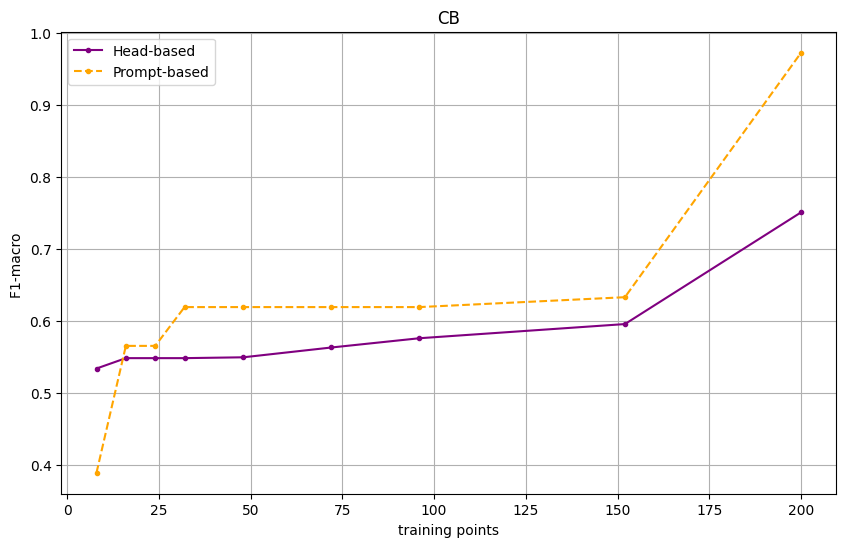

In [ ]:
import matplotlib.pyplot as plt

# make plot
plt.figure(figsize=[10,6])
plt.grid(True)
y_head = list(f1_values_head.values())        # f1-macro head
y_prompt = list(f1_values_prompt.values())    # f1-macro prompt
x = [8, 16, 24, 32, 48, 72, 96, 152, 200]   # training points

plt.plot(x, y_head, color = '#800080', label='Head-based', linestyle= '-', marker='.')
plt.plot(x, y_prompt, color = '#FFA500', label = 'Prompt-based', linestyle='--', marker = '.' )

plt.title("CB")
plt.xlabel("training points")
plt.ylabel("F1-macro ")
plt.legend()

plt.show()

### Task 1.4


Yes it could be feasible, but it would require additional computations. With single token verbalizer lables (such as, for example, "positive", "negative", "maybe"), the model predicts which token is most likely to be at the masked position.
When tokenized into mutliple sub-tokens (e.g. "pos", "-itive", "neg", "-ative"), promt-based tuning could still be feasible by computing the joint probability of each sequence of sub-tokens.
In essence, the first sub-token with the highest probability for a given promt could be selected by the model. Subsequently, conditional probabilities will be calculated for the remaining sub-tokens, given the first selected token. The sub-token with the highest conditional probability will be selected to follow the first sub-token. This procedure will be iteratively repeated, once a sub-token with some sort of an end-statement is selected, indicating that the equence is complete. To get the final score for the label corresponding to a sequence of tokens, they multiply these conditional probabilities. The label with the highest joint probability is selected.


## Task #2
Repeat the same experimental procedure for the BoolQ task (corresponding to the second panel in Figure 1). To reduce computational overhead, restrict the training set size of BoolQ to a maximum of 2,000 data points. When loading the dataset and after shuffling it with seed=42, use the first 500 examples as the test set and the subsequent 2,000 examples as the training set (8 pts).
Points are awarded for the following sub-tasks:

* __2.1.__ Run the head-based classifier on the BoolQ task, at varying training data sizes ([8, 16, 24, 32, 48, 72, 96, 152, 200, 320, 504, 704, 800, 1000, 2000]) (2 pts)

* __2.3.__ Run the prompt-based classifier on the BoolQ task using "yes" or "no" as verbalizers for True and False, at varying data sizes ([8, 16, 24, 32, 48, 72, 96, 152, 200, 320, 504, 704, 800, 1000, 2000]) (2 pts)

* __2.3.__ Reproduce the plots (again you can leave visual descriptors concerning the advantage  and region of comparison out) (4 pts)

For this experiment, you will need to modify the number of output labels and adapt the preprocessing functions. For prompt-based tuning, use the first cloze-style pattern, specified in Appendix A in the paper;
Given a passage p and question q:

___p.___ ___Question:___ ___q?___ ___Answer:___ ___


__Note__: For both Tasks #1 and #2, you are allowed to run experiments multiple times and report the average results. You may also vary the number of training epochs. However, you are not allowed to change the random seed used for shuffling the original data, the learning rate, the target models, the pattern and verbalizer, or any other components of the experimental setup beyond these allowances.

In [ ]:
#Load Data
data = load_dataset("super_glue", "boolq")
# Shuffle data
data = data.shuffle(seed=42)
# Use first 500 for test, next 2000 for training
test_data = data['train'].select(range(500))
train_data = data['train'].select(range(500, 2500))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

boolq/train-00000-of-00001.parquet:   0%|          | 0.00/3.85M [00:00<?, ?B/s]

boolq/validation-00000-of-00001.parquet:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

boolq/test-00000-of-00001.parquet:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9427 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3270 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3245 [00:00<?, ? examples/s]

### Task 2.1

In [ ]:
# Task 2.1
METHOD = "head" # @param ["head", "prompt"]
EPOCHS = [20,25,30]
LEARNING_RATE = 1e-5
MODEL_PATH = "FacebookAI/roberta-base"
BATCH_SIZE = 8
MAXL_LENGTH = 92
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data size to test
data_sizes = [8, 16, 24, 32, 48, 72, 96, 152, 200, 320, 504, 704, 800, 1000, 2000]

# Store all result
all_results_head_qbool = {epoch: [] for epoch in EPOCHS}

# Run experiments for each epoch
for e in EPOCHS:
    print(f"\nRunning experiments for {e} epochs")
    results_head_qbool = {}  # store F1 for current run
# Run training & eval
    for num_ex in data_sizes:
        print(f"\n\nRunning experiment for {num_ex} examples...")

        # Re-initialize Model & Tokenizer
        tokenizer = RobertaTokenizer.from_pretrained(MODEL_PATH)
        config = RobertaConfig.from_pretrained(MODEL_PATH)
        config.num_labels = 2
        model = RobertaForSequenceClassification.from_pretrained(MODEL_PATH, config=config)
        model.to(device)
        optimizer = AdamW(params=model.parameters(), lr=LEARNING_RATE)
        metric = load_metric("f1")

        # Subset data
        current_train = train_data.select(range(num_ex))

        # Preprocessing
        def preprocess_func(examples):
            return tokenizer(
                examples['passage'],
                examples['question'],
                truncation='only_first',
                padding="max_length",
                max_length=MAXL_LENGTH
            )

        # Tokenize and format for PyTorch
        train_dataset = current_train.map(preprocess_func, batched=True)
        test_dataset = test_data.map(preprocess_func, batched=True)

        # Set columns for model input
        train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
        test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

        # Rename 'answer' to 'labels' for HuggingFace models
        train_dataset = train_dataset.rename_column("label", "labels")
        test_dataset = test_dataset.rename_column("label", "labels")
        train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

        # Training Loop
        model.train()
        for e_indx in range(e):
            for batch in train_dataloader:
                batch = {k: v.to(device) for k, v in batch.items()}
                outputs = model(**batch)
                loss = outputs.loss
                loss.backward()
                optimizer.step()
                optimizer.zero_grad()

        # Evaluation
        model.eval()
        all_preds = []
        all_refs = []
        for batch in test_dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            with torch.no_grad():
                outputs = model(**batch)

            preds = torch.argmax(outputs.logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_refs.extend(batch["labels"].cpu().numpy())

        # Calculate Result
        f1_score = metric.compute(predictions=all_preds, references=all_refs, average="macro")['f1']
        results_head_qbool[num_ex] = f1_score
        print(f"F1 for {num_ex}: {f1_score}")
    # Store the results of this run for this epoch
    all_results_head_qbool[e].append(results_head_qbool)

# Compute average F1 per epoch across all data sizes
average_results = {}
overall_avg_per_epoch = {}

for epoch, runs in all_results_head_qbool.items():
    average_results[epoch] = {}
    for size in data_sizes:
        f1_list = [run[size] for run in runs]
        average_results[epoch][size] = np.mean(f1_list)
    overall_avg_per_epoch[epoch] = np.mean(list(average_results[epoch].values()))

# Pick the best epoch
best_epoch = max(overall_avg_per_epoch, key=lambda e: overall_avg_per_epoch[e])

# Store best epoch
best_results_head_qbool = average_results[best_epoch]

print(f"\nBest epoch: {best_epoch}")
print("F1 results for best epoch:")
print(best_results_head_qbool)


Running experiments for 20 epochs


Running experiment for 8 examples...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


F1 for 1000: 0.6535383270319164


Running experiment for 2000 examples...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


F1 for 2000: 0.6821360457724095

Best epoch: 30
F1 results for best epoch:
{8: np.float64(0.3993313700050113), 16: np.float64(0.5217122700731381), 24: np.float64(0.48221431300396134), 32: np.float64(0.49623659100337814), 48: np.float64(0.45108881905680215), 72: np.float64(0.5166237271500429), 96: np.float64(0.5297280681229039), 152: np.float64(0.5571340121078702), 200: np.float64(0.5205590412932208), 320: np.float64(0.5605562226979237), 504: np.float64(0.5610450155904702), 704: np.float64(0.6095351094811778), 800: np.float64(0.6472170081339776), 1000: np.float64(0.6535383270319164), 2000: np.float64(0.6821360457724095)}


**Task 2.1: Results with different number of training epochs 20, 25, 30**

Results for 20 epochs:

8: {'f1': 0.3932038834951456}
16: {'f1': 0.5025661271219898}
24: {'f1': 0.49698448648564986}
32: {'f1': 0.45921538978494625}
48: {'f1': 0.47634795259788165}
72: {'f1': 0.4698544698544699}
96: {'f1': 0.5189629854676185}
152: {'f1': 0.5321054380717496}
200: {'f1': 0.5390059140142203}
320: {'f1': 0.567615016578379}
504: {'f1': 0.5372582443362561}
704: {'f1': 0.5620078507133354}
800: {'f1': 0.5452103468635472}
1000: {'f1': 0.671956652397928}
2000: {'f1': 0.6829044117647058}

Average F1 for 20 epochs: 0.5303

Results Table for 25:

8: {'f1': 0.3985620164575303}
16: {'f1': 0.5115383252597958}
24: {'f1': 0.4926722068511525}
32: {'f1': 0.44323243341514407}
48: {'f1': 0.4381448564715497}
72: {'f1': 0.5019016071647651}
96: {'f1': 0.4979731251407552}
152: {'f1': 0.5388015802572269}
200: {'f1': 0.5624195624195625}
320: {'f1': 0.5392510099355825}
504: {'f1': 0.5584102769971899}
704: {'f1': 0.6172928309264281}
800: {'f1': 0.6128033040784719}
1000: {'f1': 0.6739596739596739}
2000: {'f1': 0.6921283566234706}

Average F1 for 25 epochs: 0.5386

Results Table for 30:

8: {'f1': 0.3993313700050113}
16: {'f1': 0.5217122700731381}
24: {'f1': 0.48221431300396134}
32: {'f1': 0.49623659100337814}
48: {'f1': 0.45108881905680215}
72: {'f1': 0.5166237271500429}
96: {'f1': 0.5297280681229039}
152: {'f1': 0.5571340121078702}
200: {'f1': 0.5205590412932208}
320: {'f1': 0.5605562226979237}
504: {'f1': 0.5610450155904702}
704: {'f1': 0.6095351094811778}
800: {'f1': 0.6472170081339776}
1000: {'f1': 0.6535383270319164}
2000: {'f1': 0.6821360457724095}
Average F1 for 30 epochs: 0.5460

Best number of epochs: 30 with avg F1: 0.5460

In [ ]:
best_results_head_qbool = {8: 0.3993313700050113, 16: 0.5217122700731381, 24: 0.48221431300396134, 32: 0.49623659100337814, 48: 0.45108881905680215, 72: 0.5166237271500429, 96: 0.5297280681229039, 152: 0.5571340121078702, 200: 0.5205590412932208, 320: 0.5605562226979237, 504: 0.5610450155904702, 704: 0.6095351094811778, 800: 0.6472170081339776, 1000: 0.6535383270319164, 2000: 0.6821360457724095}

### Task 2.2

In [ ]:
# Task 2.2 — Prompt-based BoolQ

import numpy as np
import torch
from torch.utils.data import DataLoader
from transformers import default_data_collator
from torch.optim import AdamW
from datasets import load_dataset
from transformers import RobertaTokenizer, RobertaForMaskedLM
from sklearn.metrics import f1_score

# ===== Settings =====
METHOD = "prompt"
MODEL_PATH = "FacebookAI/roberta-base"
LEARNING_RATE = 1e-5
BATCH_SIZE = 8
MAXL_LENGTH = 256
NUM_EXAMPLES_LIST = [8, 16, 24, 32, 48, 72, 96, 152, 200, 320, 504, 704, 800, 1000, 2000]
EPOCHS = 20

# BoolQ labels: 0=False, 1=True
VERBALIZER = {0: "no", 1: "yes"}

# ===== Device =====
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("Using CPU")

# ===== Helper functions =====
def load_model_tokenizer_prompt(model_path, device):
    tokenizer = RobertaTokenizer.from_pretrained(model_path)
    model = RobertaForMaskedLM.from_pretrained(model_path)
    model.to(device)
    return model, tokenizer

def preprocessing_prompt_boolq(example, tokenizer):
    """
    Put the mask BEFORE the long passage, so truncation won't remove it.
    Pattern used here:
    Question: ...? Answer: <mask> Passage: ...
    """
    max_len = MAXL_LENGTH

    prefix = f"Question: {example['question']}? Answer: {tokenizer.mask_token} Passage:"
    prefix_ids = tokenizer.encode(prefix, add_special_tokens=False)

    # Reserve space for prefix + BOS/EOS
    remaining_len = max_len - len(prefix_ids) - 2

    passage_ids = tokenizer.encode(
        " " + example["passage"],
        truncation=True,
        max_length=remaining_len,
        add_special_tokens=False
    )

    input_ids = [tokenizer.bos_token_id] + prefix_ids + passage_ids + [tokenizer.eos_token_id]

    pad_len = max_len - len(input_ids)
    if pad_len > 0:
        input_ids = input_ids + [tokenizer.pad_token_id] * pad_len

    attention_mask = [1] * (max_len - pad_len) + [0] * pad_len
    masked_index = input_ids.index(tokenizer.mask_token_id)

    features = {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "masked_indices": masked_index,
        "labels": example["label"]
    }
    return features

def eval_prompt(model, tokenizer, test_dataloader, device):
    predictions = []
    references = []
    model.eval()

    target_ids = torch.tensor(
        [tokenizer.convert_tokens_to_ids(v) for v in VERBALIZER.values()],
        device=device
    )

    for batch in test_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}

        with torch.no_grad():
            outputs = model(batch["input_ids"], attention_mask=batch["attention_mask"])

        logits = outputs.logits
        masked_logits = logits[torch.arange(logits.size(0)), batch["masked_indices"]]
        logits_of_interest = masked_logits[:, target_ids]
        preds = torch.argmax(logits_of_interest, dim=-1)

        predictions.extend(preds.cpu().tolist())
        references.extend(batch["labels"].cpu().tolist())

    return {"f1": f1_score(references, predictions, average="macro")}

def train_prompt(model, tokenizer, train_dataloader, test_dataloader, epochs, device):
    optimizer = AdamW(params=model.parameters(), lr=LEARNING_RATE)

    target_ids = torch.tensor(
        [tokenizer.convert_tokens_to_ids(v) for v in VERBALIZER.values()],
        device=device
    )

    for e in range(epochs):
        print(f"\n===== Epoch {e+1}/{epochs} =====")
        model.train()

        for batch in train_dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(batch["input_ids"], attention_mask=batch["attention_mask"])

            logits = outputs.logits
            masked_logits = logits[torch.arange(logits.size(0)), batch["masked_indices"]]
            logits_of_interest = masked_logits[:, target_ids]
            loss = torch.nn.functional.cross_entropy(logits_of_interest, batch["labels"])

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad()

        perf = eval_prompt(model, tokenizer, test_dataloader, device)
        print(f"Test F1 after epoch {e+1}: {perf['f1']:.4f}")

    return model, perf

# ===== Load BoolQ data =====
# Assignment requirement:
# shuffle with seed=42
# first 500 = test
# next 2000 = training pool
data = load_dataset("super_glue", "boolq", split="train").shuffle(seed=42)
test_data = data.select(range(500))
train_pool = data.select(range(500, 2500))

results_prompt_qbool = {}

# ===== Run experiments =====
for num_examples in NUM_EXAMPLES_LIST:
    print(f"\n===== Running prompt-based BoolQ with {num_examples} examples =====")

    train_data = train_pool.select(range(num_examples))

    model, tokenizer = load_model_tokenizer_prompt(MODEL_PATH, device)

    train_dataset = train_data.map(
        preprocessing_prompt_boolq,
        fn_kwargs={"tokenizer": tokenizer},
        remove_columns=train_data.column_names
    )
    test_dataset = test_data.map(
        preprocessing_prompt_boolq,
        fn_kwargs={"tokenizer": tokenizer},
        remove_columns=test_data.column_names
    )

    train_dataloader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=default_data_collator,
        pin_memory=True
    )
    test_dataloader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=default_data_collator,
        pin_memory=True
    )

    model, performance = train_prompt(
        model=model,
        tokenizer=tokenizer,
        train_dataloader=train_dataloader,
        test_dataloader=test_dataloader,
        epochs=EPOCHS,
        device=device
    )

    results_prompt_qbool[num_examples] = performance["f1"]
    print(f"F1 for {num_examples} examples: {performance['f1']:.4f}")

print("\nresults_prompt_qbool =")
print(results_prompt_qbool)

Using GPU: Tesla T4

===== Running prompt-based BoolQ with 8 examples =====


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

RobertaForMaskedLM LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Map:   0%|          | 0/8 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

...


===== Epoch 1/20 =====
Test F1 after epoch 1: 0.6302

===== Epoch 2/20 =====
Test F1 after epoch 2: 0.6695

===== Epoch 3/20 =====
Test F1 after epoch 3: 0.6708

===== Epoch 4/20 =====
Test F1 after epoch 4: 0.6822

===== Epoch 5/20 =====
Test F1 after epoch 5: 0.6812

===== Epoch 6/20 =====
Test F1 after epoch 6: 0.7128

===== Epoch 7/20 =====
Test F1 after epoch 7: 0.6959

===== Epoch 8/20 =====
Test F1 after epoch 8: 0.7178

===== Epoch 9/20 =====
Test F1 after epoch 9: 0.7026

===== Epoch 10/20 =====
Test F1 after epoch 10: 0.7099

===== Epoch 11/20 =====
Test F1 after epoch 11: 0.7150

===== Epoch 12/20 =====
Test F1 after epoch 12: 0.7105

===== Epoch 13/20 =====
Test F1 after epoch 13: 0.7117

===== Epoch 14/20 =====
Test F1 after epoch 14: 0.7211

===== Epoch 15/20 =====
Test F1 after epoch 15: 0.7166

===== Epoch 16/20 =====
Test F1 after epoch 16: 0.7025

===== Epoch 17/20 =====
Test F1 after epoch 17: 0.7114

===== Epoch 18/20 =====
Test F1 after epoch 18: 0.7296

===== Epo

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

RobertaForMaskedLM LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]


===== Epoch 1/20 =====
Test F1 after epoch 1: 0.6383

===== Epoch 2/20 =====
Test F1 after epoch 2: 0.7159

===== Epoch 3/20 =====
Test F1 after epoch 3: 0.7393

===== Epoch 4/20 =====
Test F1 after epoch 4: 0.7540

===== Epoch 5/20 =====
Test F1 after epoch 5: 0.7275

===== Epoch 6/20 =====
Test F1 after epoch 6: 0.7500

===== Epoch 7/20 =====
Test F1 after epoch 7: 0.7501

===== Epoch 8/20 =====
Test F1 after epoch 8: 0.7483

===== Epoch 9/20 =====
Test F1 after epoch 9: 0.7342

===== Epoch 10/20 =====
Test F1 after epoch 10: 0.7432

===== Epoch 11/20 =====
Test F1 after epoch 11: 0.7564

===== Epoch 12/20 =====
Test F1 after epoch 12: 0.7306

===== Epoch 13/20 =====
Test F1 after epoch 13: 0.7438

===== Epoch 14/20 =====
Test F1 after epoch 14: 0.7712

===== Epoch 15/20 =====
Test F1 after epoch 15: 0.7459

===== Epoch 16/20 =====
Test F1 after epoch 16: 0.7816

===== Epoch 17/20 =====
Test F1 after epoch 17: 0.7449

===== Epoch 18/20 =====
Test F1 after epoch 18: 0.7577

===== Epo

In [ ]:
results_prompt_qbool = {8: 0.5697093000163289, 16: 0.48266666666666663, 24: 0.483200263642764, 32: 0.5225362872421696, 48: 0.5273189829686348, 72: 0.5478026273433787, 96: 0.540495443460403, 152: 0.5925297113752122, 200: 0.5926145857787966, 320: 0.6619337390128466, 504: 0.666737930253908, 704: 0.7041738382099827, 800: 0.7156300087896179, 1000: 0.6958901729081588, 2000: 0.7854116443860033}

### Task 2.3

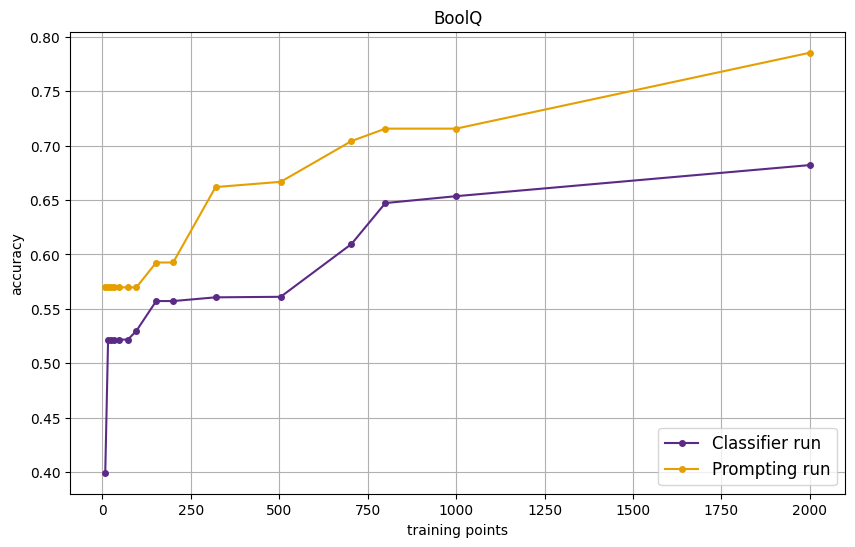

In [ ]:
import matplotlib.pyplot as plt

head_qbool_results = []
current_best_head_qbool = 0
for i in best_results_head_qbool.values():
  if i > current_best_head_qbool:
    current_best_head_qbool = i
    head_qbool_results.append(i)
  else:
    head_qbool_results.append(current_best_head_qbool)

prompt_qbool_results = []
current_best_prompt_qbool = 0
for j in results_prompt_qbool.values():
  if j > current_best_prompt_qbool:
    current_best_prompt_qbool = j
    prompt_qbool_results.append(j)
  else:
    prompt_qbool_results.append(current_best_prompt_qbool)

x_trainingpoints_boolq = [8, 16, 24, 32, 48, 72, 96, 152, 200, 320, 504, 704, 800, 1000, 2000]  # training data sizes
y_head_boolq = head_qbool_results  # best results from head-based approach for BoolQ
y_prompt_boolq = prompt_qbool_results   # best results form prompt-based approach for BoolQ

plt.figure(figsize=[10,6])
plt.grid(True)
plt.plot(x_trainingpoints_boolq, y_head_boolq, color = '#5b2a86', label='Classifier run', linestyle= '-', marker='.', markersize = 8)   # create the line graph of head-based approach
plt.plot(x_trainingpoints_boolq, y_prompt_boolq, color = '#e69f00', label = 'Prompting run', linestyle='-', marker = '.', markersize = 8)  # create the line graph of prompt-based approach


plt.title("BoolQ")
plt.xlabel("training points")
plt.ylabel("accuracy")

plt.legend(loc= "lower right", fontsize=12, frameon=True)
plt.show()

## Task #3
This project introduces two approaches for fine-tuning language models: head-based fine-tuning and prompt-based fine-tuning, both of which update all model parameters using gradient updates. There are several alternative approaches for adapting LLMs to downstream tasks, including parameter-efficient fine-tuning (PEFT) methods (e.g., LoRA), as well as In-Context Learning (ICL) where task behavior is induced through few demonstrations in the input prompt at inference time.
Study about PEFT and ICL, to answer following sub-tasks (4 pts in total):

* __3.1.__ Highlight at least two advantages and two disadvantages of prompt-based tuning compared to head-based tuning. (2 pts)

* __3.2.__ Discuss the advantages of PEFT and ICL seperately compared to head-based and prompt-based fine-tuning approaches, especially when applied to very large-scale language models with billions of parameters. (2 pts)

__Note__: Please keep your answers clear and concise, with a maximum of 150 words for each sub-task. Any text beyond this limit will not be counted.

### Task 3.1

Prompt-based tuning has both advantages and disadvantages. Its main advantages are better alignment with pre-training objectives and greater effectiveness with limited training data. By reformulating tasks as masked-token prediction problems, it aligns closely with how models like RoBERTa were trained, allowing them to leverage pre-trained knowledge more effectively. Additionally, because it reuses the pre-trained language modeling head instead of adding a new classification head, it performs better when only a small number of labeled examples are available. However, prompt-based tuning also has drawbacks. It is highly sensitive to prompt design, so poorly chosen prompts or verbalizers can lead to misunderstandings and worse results. It also depends on mapping labels to specific vocabulary tokens, which can be challenging when labels require multiple sub-tokens or lack clear verbalizers, making the tuning process less reliable and harder to implement consistently.

### Task 3.2

PEFT methods train only a small subset of parameters and keep the pretrained model usually the same. This is a major advantage compared to prompt-based approaches as these train many or all of the model parameters. PEFT is therefore less computationally expensive and uses less memory storage, which makes it more suitable for large-scale language models. Compared to head-based approaches, PEFT has a higher flexibility because it can adapt internal layers of the model while keeping the rest of the model the same. Head-based approaches can only change the final output layer and the model needs to be retrained in case an internal layers needs to be adjusted. This can become very computationally expensive with large models.

ICL requires no training at all. The model learns the task from examples provided in the prompt. This makes the method very efficient and much less computationally expensive than prompt-based and head-based approaches.